In [31]:
# %pip install torchsummary

In [ ]:
### Basic Imports
import numpy as np
import matplotlib.pyplot as plt
import os
import random
from PIL import Image
from pathlib import Path
###pytorch
# import torch
# import torch.nn as nn
from torchvision.transforms import v2
from torchsummary import summary
import glob
import torchmetrics
from torchmetrics import MetricCollection
from torchmetrics.classification import MulticlassAccuracy

In [2]:
data_dir = Path('../../dataset/Rock-Paper-Scissor')
train_data_dir = data_dir/"train"/"rps"
test_data_dir = data_dir/"test"/"rps-test-set"

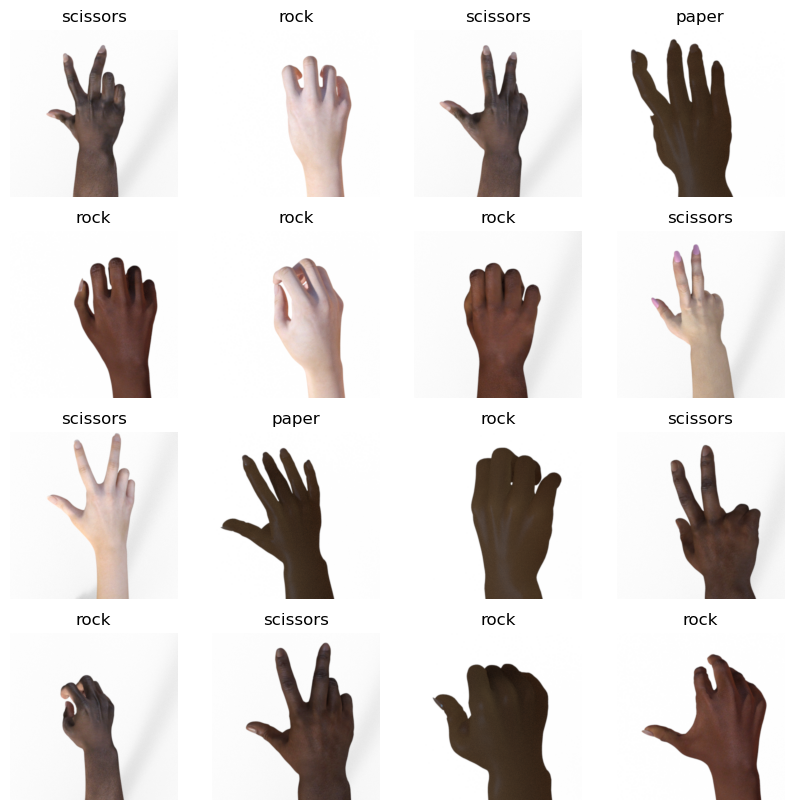

In [3]:
classes = ["rock", "paper", "scissors"]
nrows = 4
ncols = 4

plt.figure(figsize=(10, 10))
for i in range(1, nrows*ncols+1):
    random_class = random.choice(classes)
    random_path = os.path.join(data_dir, "train", "rps", random_class)
    random_image_path = random.choice(glob.glob(os.path.join(random_path, "*.png")))
    img = Image.open(random_image_path)
    plt.subplot(nrows, ncols, i)
    plt.imshow(img)
    plt.title(f'{random_class}')
    plt.axis(False)
    
    
    


In [5]:
train_transform = v2.Compose([
    v2.RandomHorizontalFlip(p=0.4),
    v2.RandomRotation(degrees=30),
    v2.Resize((256,256)),
    v2.ToTensor(),
    v2.ToDtype(torch.float32),
    v2.Normalize(mean=[0.5]*3, std=[0.5]*3),
    
]
)

test_transform = v2.Compose([
    v2.Resize((256,256)),
    v2.ToTensor(),
    v2.ToDtype(torch.float32),
    v2.Normalize(mean=[0.5]*3, std=[0.5]*3), 
]
)

In [6]:
from src.data_setup import create_dataloaders
BATCH_SIZE=32

train_loader, test_loader, valid_loader = create_dataloaders(
    train_dir=train_data_dir, test_dir=test_data_dir, batch_size=BATCH_SIZE, 
    train_transform=train_transform, test_transform=test_transform)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


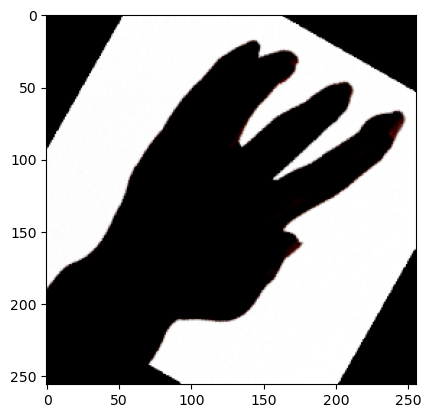

In [11]:
img, label = next(iter(train_loader))
plt.imshow(img[0].permute(1,2, 0))


In [ ]:
from src.model import RPSNet
from src.train import train_model

In [41]:
def init_weight(module):
    if isinstance(module, (nn.Conv2d, nn.Linear)):
        nn.init.kaiming_uniform(module.weight, mode="fan_in", nonlinearity="relu")
        if module.bias is not None:
            nn.init.constant_(module.bias, 0)
    elif isinstance(module, nn.BatchNorm2d):
        nn.init.constant_(module.weight, 1)
        nn.init.constant_(module.bias, 0)

In [43]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = RPSNet(in_channels=3, num_classes=3).to(device)
model.apply(init_weight)

loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=0.001)
metrics = MulticlassAccuracy(num_classes=3).to(device)

results = train_model(
    model=model, epochs=20, train_loader=train_loader, 
    test_loader=test_loader, device=device, metrics=metrics,
    optimizer=optimizer, loss_func=loss_func)

C:\Users\Global Lecturer\AppData\Local\Temp\ipykernel_3628\3196684825.py:3: FutureWarning: `nn.init.kaiming_uniform` is now deprecated in favor of `nn.init.kaiming_uniform_`.
  nn.init.kaiming_uniform(module.weight, mode="fan_in", nonlinearity="relu")


epoch: 1/20 train loss: 1.3595183287994772 test loss: 0.9520974685164059 train acc: 0.4234127104282379 test acc: 0.4905303120613098
best model saved
epoch: 2/20 train loss: 0.9065782095812545 test loss: 0.8227926422567928 train acc: 0.5825396776199341 test acc: 0.5546085834503174
best model saved
epoch: 3/20 train loss: 0.7423258269134956 test loss: 0.7382717693553251 train acc: 0.6757936477661133 test acc: 0.6726641654968262
best model saved
epoch: 4/20 train loss: 0.6228652762461312 test loss: 0.6494424921624801 train acc: 0.7464285492897034 test acc: 0.7446337938308716
best model saved
epoch: 5/20 train loss: 0.5235877542556087 test loss: 0.5898348899448619 train acc: 0.8083333373069763 test acc: 0.778724730014801
best model saved
epoch: 6/20 train loss: 0.4677158586586578 test loss: 0.5229440331459045 train acc: 0.8269840478897095 test acc: 0.8200757503509521
best model saved
epoch: 7/20 train loss: 0.38589617911773394 test loss: 0.4776554195319905 train acc: 0.874603271484375 test

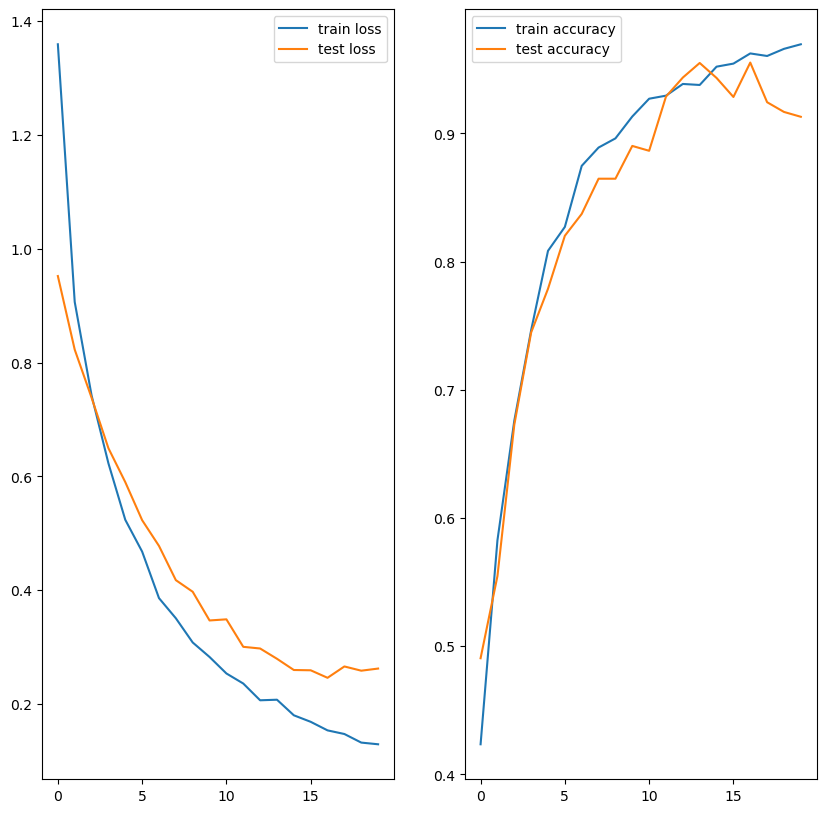

In [44]:
x_range = list(range(len(results["train_loss"])))
fig, ax = plt.subplots(1, 2, figsize=(10, 10))
ax= ax.flatten()
ax[0].plot(x_range, results["train_loss"], label="train loss")
ax[0].plot(x_range, results["test_loss"], label="test loss")
ax[0].legend()
ax[1].plot(x_range, results["train_acc"], label="train accuracy")
ax[1].plot(x_range, results["test_acc"], label="test accuracy")
ax[1].legend()

    

In [46]:
valid_loss, valid_acc= eval_model(model=model, dataloader=valid_loader, loss_func=loss_func, metrics=metrics, device=device)


In [47]:
print(f'valid loss: {valid_loss} '
      f'valid acc: {valid_acc}'
      )

valid loss: 0.2620805773664923 valid acc: 0.9128788709640503
